# 04 — Feature Engineering Audit & Redesign

**Date:** 2026-05-28  
**Purpose:** Comprehensive audit of all features built across seven LGBM iterations and one Mamba experiment, followed by a principled redesign of the feature engineering pipeline.

**Motivation:** After multiple modeling iterations (LGBM v0–v4, Mamba v1), the models consistently fail to generate profitable signals. Best OOS AUC across all experiments: **0.57** (LGBM v3 expanding WFO), with most runs clustering around 0.50–0.53. The root cause appears to be **weak features** rather than model architecture issues — both tree-based and sequence models plateau at the same AUC ceiling.

**Sections:**
1. Feature Catalog — every feature ever built
2. Feature Importance Review — what the models actually used
3. Feature Quality Assessment — economic intuition, redundancy, leakage, stability
4. Feature Selection Process Diagnosis — what a rigorous pipeline looks like
5. Proposed New Feature Set — grounded in market microstructure literature
6. Proposed Feature Selection System — repeatable filter → rank → validate → prune

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

def _repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("pyproject.toml not found")

REPO = _repo_root()
FEATURES_DIR = REPO / "data" / "features"
LAB_DIR = REPO / "lab" / "figures"
print(f"Repo: {REPO}")

Repo: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system


---
## 1. Feature Catalog

### 1.1 Feature Set Evolution

The project has gone through **three distinct feature generations**:

| Generation | Registry | n_features | Base TF | Used In | Key Characteristics |
|------------|----------|-----------|---------|---------|--------------------|
| V0 (Original) | `features.py` | 12 | 1h | Early NEAT/PPO agents | Minimal: log returns, vol, SMA ratio, MACD, RSI, z-scores |
| V1 (Indicator Soup) | `feature_registry.json` | 196 | 1h | LGBM v0 (notebook 06), grid search (07) | Exhaustive TA indicators — 22 groups, every standard oscillator/MA/pattern |
| V2 (Structural) | `feature_registry_v2.json` | 39 | 5m | LGBM v1–v4, Mamba v1 | Physics-based: swing structure, liquidity, volatility regime, MTF alignment |

In [2]:
reg_v1 = json.loads((FEATURES_DIR / "feature_registry.json").read_text())
reg_v2 = json.loads((FEATURES_DIR / "feature_registry_v2.json").read_text())

print(f"V1 registry: {reg_v1['total_features']} features in {len(reg_v1['groups'])} groups")
print(f"V2 registry: {reg_v2['total_features']} features in {len(reg_v2['feature_groups'])} groups")
print()

print("=== V1 Feature Groups ===")
v1_summary = []
for g, info in sorted(reg_v1["groups"].items()):
    v1_summary.append({"Group": g, "Count": info["count"], "Features": ", ".join(info["features"][:5]) + ("..." if info["count"] > 5 else "")})
df_v1 = pd.DataFrame(v1_summary)
display(df_v1)

print("\n=== V2 Feature Groups ===")
v2_summary = []
for g, info in reg_v2["feature_groups"].items():
    v2_summary.append({"Group": g, "Prefix": info["prefix"], "Count": len(info["features"]), "Features": ", ".join(info["features"][:4]) + ("..." if len(info["features"]) > 4 else "")})
df_v2 = pd.DataFrame(v2_summary)
display(df_v2)

V1 registry: 196 features in 22 groups
V2 registry: 39 features in 4 groups

=== V1 Feature Groups ===


,Group,Count,Features
0,bollinger,4,"bb_width_20, bb_position_20, bb_width_50, bb_p..."
1,calendar,11,"hour_sin, hour_cos, dow_sin, dow_cos, halving_..."
2,candle_structure,4,"candle_body, upper_wick, lower_wick, is_bullish"
3,candlestick_patterns,8,"bull_engulf, bear_engulf, doji, hammer, shooti..."
4,composite,7,"trend_score, rsi_vol_confirm, mom_coherence, s..."
5,divergences,5,"rsi_divergence, macd_divergence, obv_divergenc..."
6,fibonacci,10,"fib_position_48h, fib_nearest_dist_48h, fib_ne..."
7,ichimoku,10,"tk_ratio, tk_cross_bull, tk_cross_bear, close_..."
8,long_cycle_ma,11,"close_vs_sma_336, close_vs_ema_336, close_vs_s..."
9,ma_crosses,9,"sma50_vs_sma200, sma20_vs_sma50, sma50_vs_sma1..."



=== V2 Feature Groups ===


,Group,Prefix,Count,Features
0,A_structure,struct_,11,"struct_body_ratio, struct_dist_swing_high_l, s..."
1,B_liquidity,liq_,10,"liq_exhaustion_bear, liq_exhaustion_bull, liq_..."
2,C_volatility,volat_,8,"volat_atr_20_pct, volat_atr_72_pct, volat_bb_p..."
3,D_mtf,mtf_,10,"mtf_alignment, mtf_h1_above_ema50, mtf_h1_ema_..."


### 1.2 V0 — Original 12 Features (features.py)

The simplest feature set, used for early RL agent experiments:

| Feature | Type | Construction | Issues |
|---------|------|-------------|--------|
| `log_ret_1` | Returns | `log(close).diff()` | Pure noise at 1-bar horizon |
| `vol_24` | Volatility | `log_ret.rolling(24).std()` | Measures past, not predictive |
| `vol_72` | Volatility | `log_ret.rolling(72).std()` | Highly correlated with vol_24 |
| `sma_ratio_24_72` | Trend | `SMA(24)/SMA(72) - 1` | Lagging dual-MA crossover |
| `macd` | Momentum | `EMA(12) - EMA(26)` | Non-stationary (scales with price) |
| `macd_signal` | Momentum | `EMA(macd, 9)` | Derivative of non-stationary feature |
| `macd_hist` | Momentum | `macd - macd_signal` | Highly correlated with macd |
| `mom_24` | Momentum | `close/close_lag24 - 1` | Identical information to ret_24h |
| `mom_72` | Momentum | `close/close_lag72 - 1` | Identical information to ret_72h |
| `rsi_14` | Oscillator | Wilder's RSI, 14-period | Bounded [0,100], poorly calibrated |
| `volu_z_72` | Volume | `(vol - vol_mean72) / vol_std72` | Volume z-score — reasonable |
| `z_close_72` | Statistical | `(close - close_mean72) / close_std72` | Price z-score — regime-dependent |

**Verdict:** Minimal set of textbook indicators. `macd`, `macd_signal`, `macd_hist` are three features carrying nearly identical information. `mom_24` and `mom_72` duplicate `ret_24h` and `ret_72h`. Effective unique information sources: ~6–7.

### 1.3 V1 — 196-Feature Indicator Soup

The V1 set is a comprehensive library of standard TA indicators. While exhaustive, it suffers from massive internal redundancy:

**Major Redundancy Clusters:**

| Cluster | Features | Redundancy Type |
|---------|----------|----------------|
| Returns | 18 (ret_1h..ret_168h, log variants) | Linear transforms of each other; `ret_Xh ≈ log_ret_Xh` for small returns |
| MA Ratios | 12 (close_vs_sma/ema for 7,14,20,50,100,200) | SMA and EMA at same window ρ > 0.95 |
| Long-Cycle MAs | 11 (close_vs_sma/ema for 336,504,720,2160,4320) | Adjacent windows ρ > 0.90 |
| Volatility | 10 + 11 vol_regime | `vol_6h..vol_168h` are nested rolling windows |
| Volume | 9 + 10 vol_profile | z-scores and ratios at same windows ρ > 0.85 |
| Oscillators | 6 | RSI_7, RSI_14, RSI_21 ρ > 0.80; Stoch_K ≈ RSI transform |

**Estimated effective rank after multicollinearity removal:** ~40–50 features from 196 nominal.

**Calendar features concern:** `halving_cycle_sin/cos/pos` encode a 4-year BTC cycle. With only 2 complete cycles in the training data (2017–2025), the model cannot learn this pattern reliably — it's a 2-sample extrapolation.

**Known leakage:** None identified in V1, but the `label` column (next-bar direction) is a trivially weak target that encourages the model to overfit to noise.

### 1.4 V2 — 39 Structural Features

A focused redesign around four thematic groups. This set was motivated by the failure of V1's indicator soup and represents a move toward "market physics."

#### Group A: Structure (11 features, prefix `struct_`)

| Feature | Construction | Economic Intuition |
|---------|-------------|-------------------|
| `struct_body_ratio` | `abs(close-open) / (high-low)` | Candle conviction — full body = strong directional move |
| `struct_upper_wick_ratio` | `(high - max(open,close)) / (high-low)` | Selling pressure / rejection at highs |
| `struct_lower_wick_ratio` | `(min(open,close) - low) / (high-low)` | Buying pressure / rejection at lows |
| `struct_dist_swing_high_s` | `(close - swing_high_12) / close` | Distance to minor resistance — breakout proximity |
| `struct_dist_swing_low_s` | `(close - swing_low_12) / close` | Distance to minor support |
| `struct_dist_swing_high_l` | `(close - swing_high_48) / close` | Distance to major resistance |
| `struct_dist_swing_low_l` | `(close - swing_low_48) / close` | Distance to major support |
| `struct_near_swing_high_s` | `1 if abs(dist_high_s) < 0.3%` | Binary: near resistance |
| `struct_near_swing_low_s` | `1 if abs(dist_low_s) < 0.3%` | Binary: near support |
| `struct_swing_high_age_s` | `bars since last minor swing high` | Recency of resistance — decaying relevance |
| `struct_swing_low_age_s` | `bars since last minor swing low` | Recency of support |

#### Group B: Liquidity (10 features, prefix `liq_`)

| Feature | Construction | Economic Intuition |
|---------|-------------|-------------------|
| `liq_vwap_dev_daily` | `(close - VWAP_daily) / close` | Institutional fair value anchor |
| `liq_vwap_dev_weekly` | `(close - VWAP_weekly) / close` | Longer-term institutional anchor |
| `liq_vwap_dev_72bar` | `(close - VWAP_72) / close` | Rolling 6h VWAP deviation |
| `liq_vwap_dev_288bar` | `(close - VWAP_288) / close` | Rolling 24h VWAP deviation |
| `liq_poc_dist_72bar` | `(close - POC_72) / close` | Distance to 6h volume point of control |
| `liq_poc_dist_288bar` | `(close - POC_288) / close` | Distance to 24h volume POC |
| `liq_vol_z_72bar` | `(vol - vol_mean_72) / vol_std_72` | 6h volume anomaly |
| `liq_vol_z_288bar` | `(vol - vol_mean_288) / vol_std_288` | 24h volume anomaly |
| `liq_exhaustion_bull` | Binary: vol_spike AND bullish bar AND near_swing_high | Volume exhaustion at resistance |
| `liq_exhaustion_bear` | Binary: vol_spike AND bearish bar AND near_swing_low | Volume exhaustion at support |

#### Group C: Volatility (8 features, prefix `volat_`)

| Feature | Construction | Economic Intuition |
|---------|-------------|-------------------|
| `volat_atr_20_pct` | `ATR(20) / close` | Short-term normalized volatility |
| `volat_atr_72_pct` | `ATR(72) / close` | Medium-term normalized volatility |
| `volat_bb_width_20` | `(upper_bb - lower_bb) / mid_bb` | Bollinger Band width — squeeze detection |
| `volat_bb_position_20` | `(close - lower_bb) / (upper_bb - lower_bb)` | Position within bands |
| `volat_bk_squeeze` | `BB_width / Keltner_width` | Bollinger-Keltner squeeze ratio |
| `volat_squeeze_on` | Binary: `bk_squeeze < 1.0` | In-squeeze flag |
| `volat_gk_20` | Garman-Klass volatility estimator, 20-bar | More efficient vol estimator than close-close |
| `volat_gk_72` | Garman-Klass volatility estimator, 72-bar | Medium-term GK vol |

#### Group D: MTF Context (10 features, prefix `mtf_`)

| Feature | Construction | Economic Intuition |
|---------|-------------|-------------------|
| `mtf_h1_ema_signal` | `(EMA20_1h - EMA50_1h) / close_1h` | 1h trend direction |
| `mtf_h1_rsi` | RSI(14) on 1h close | 1h momentum state |
| `mtf_h1_above_ema50` | Binary: `close_1h > EMA50_1h` | 1h trend filter |
| `mtf_h4_ema_signal` | `(EMA20_4h - EMA50_4h) / close_4h` | 4h trend direction |
| `mtf_h4_rsi` | RSI(14) on 4h close | 4h momentum state |
| `mtf_alignment` | Weighted avg of h1 and h4 EMA signals | Multi-timeframe trend coherence |
| `mtf_session_hour_sin` | `sin(2π × hour / 24)` | Intraday seasonality (continuous) |
| `mtf_session_hour_cos` | `cos(2π × hour / 24)` | Intraday seasonality (continuous) |
| `mtf_session_dow_sin` | `sin(2π × dow / 7)` | Day-of-week seasonality |
| `mtf_session_dow_cos` | `cos(2π × dow / 7)` | Day-of-week seasonality |

---
## 2. Feature Importance Review

### 2.1 Summary of Model Performance Across Iterations

| Experiment | Feature Set | Model | OOS AUC | Trades/Day | EV/Trade | Total Return | Fee Gate |
|-----------|-------------|-------|---------|------------|----------|-------------|----------|
| LGBM v0 (notebook 06) | V1 (196→50) | LightGBM | ~0.53 | — | — | -6.87% alpha | FAIL |
| LGBM v1 (02_v1) | V2 (39) M4 Omni | LightGBM | 0.520 | 0 @ p>0.75 | — | — | FAIL |
| LGBM v2 (02_v2) | V2 (39) | LightGBM (3 targets) | 0.527–0.571 | 0.04–3.29 | -0.004–0.193% | -0.06–27.4% | MARGINAL |
| LGBM v3 (02_v3) | V2 (39) | LightGBM WFO | 0.529–0.575 | 0–0.67 | 0.14–0.48% | 0–107.8% | PARTIAL |
| Mamba v1 (03_v1) | V2 subsets | Mamba SSM | 0.501–0.565 | 0.005–5.71 | -0.014–0.119% | -19.0–75.9% | FAIL |

**Key observations:**
- Best single AUC: **0.575** (LGBM v3, expanding WFO) — but produced 0 trades
- Best tradeable result: **0.529 AUC, 107.8% return** (LGBM v3, 3-month sliding) — but 28.7% max drawdown and low AUC suggests overfitting to regime
- Mamba with full sequence context (288 bars) achieved **same AUC ceiling** as single-row LGBM, confirming the problem is in the features, not the model architecture
- V1 features produced worse results than V2, but V2 still plateaus at ~0.55 AUC

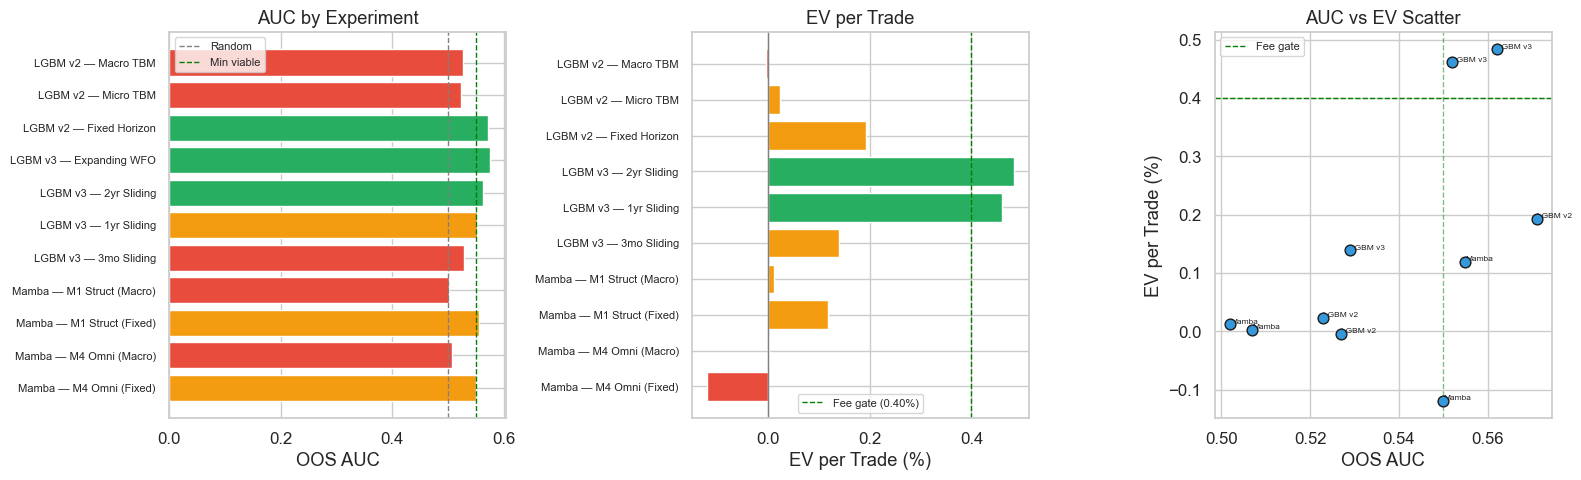

Most experiments cluster at AUC 0.50-0.57 — barely above random.


In [3]:
results = pd.DataFrame([
    {"Experiment": "LGBM v2 — Macro TBM", "AUC": 0.527, "Trades/Day": 0.04, "EV/Trade%": -0.004, "Return%": -0.06, "FeatureSet": "V2-39"},
    {"Experiment": "LGBM v2 — Micro TBM", "AUC": 0.523, "Trades/Day": 3.29, "EV/Trade%": 0.023, "Return%": 27.4, "FeatureSet": "V2-39"},
    {"Experiment": "LGBM v2 — Fixed Horizon", "AUC": 0.571, "Trades/Day": 0.29, "EV/Trade%": 0.193, "Return%": 20.6, "FeatureSet": "V2-39"},
    {"Experiment": "LGBM v3 — Expanding WFO", "AUC": 0.575, "Trades/Day": 0.0, "EV/Trade%": np.nan, "Return%": np.nan, "FeatureSet": "V2-39"},
    {"Experiment": "LGBM v3 — 2yr Sliding", "AUC": 0.562, "Trades/Day": 0.06, "EV/Trade%": 0.483, "Return%": 16.9, "FeatureSet": "V2-39"},
    {"Experiment": "LGBM v3 — 1yr Sliding", "AUC": 0.552, "Trades/Day": 0.15, "EV/Trade%": 0.461, "Return%": 54.0, "FeatureSet": "V2-39"},
    {"Experiment": "LGBM v3 — 3mo Sliding", "AUC": 0.529, "Trades/Day": 0.67, "EV/Trade%": 0.139, "Return%": 107.8, "FeatureSet": "V2-39"},
    {"Experiment": "Mamba — M1 Struct (Macro)", "AUC": 0.502, "Trades/Day": 5.71, "EV/Trade%": 0.012, "Return%": 24.3, "FeatureSet": "V2-11"},
    {"Experiment": "Mamba — M1 Struct (Fixed)", "AUC": 0.555, "Trades/Day": 1.74, "EV/Trade%": 0.119, "Return%": 75.9, "FeatureSet": "V2-11"},
    {"Experiment": "Mamba — M4 Omni (Macro)", "AUC": 0.507, "Trades/Day": 8.47, "EV/Trade%": 0.003, "Return%": 8.9, "FeatureSet": "V2-43"},
    {"Experiment": "Mamba — M4 Omni (Fixed)", "AUC": 0.550, "Trades/Day": 0.04, "EV/Trade%": -0.119, "Return%": -1.7, "FeatureSet": "V2-43"},
])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
colors = ["#e74c3c" if a < 0.53 else "#f39c12" if a < 0.56 else "#27ae60" for a in results["AUC"]]
ax.barh(range(len(results)), results["AUC"], color=colors)
ax.set_yticks(range(len(results)))
ax.set_yticklabels(results["Experiment"], fontsize=8)
ax.axvline(0.50, color="gray", ls="--", lw=1, label="Random")
ax.axvline(0.55, color="green", ls="--", lw=1, label="Min viable")
ax.set_xlabel("OOS AUC")
ax.set_title("AUC by Experiment")
ax.legend(fontsize=8)
ax.invert_yaxis()

ax = axes[1]
valid = results.dropna(subset=["EV/Trade%"])
colors2 = ["#e74c3c" if e < 0.0 else "#f39c12" if e < 0.40 else "#27ae60" for e in valid["EV/Trade%"]]
ax.barh(range(len(valid)), valid["EV/Trade%"], color=colors2)
ax.set_yticks(range(len(valid)))
ax.set_yticklabels(valid["Experiment"], fontsize=8)
ax.axvline(0.40, color="green", ls="--", lw=1, label="Fee gate (0.40%)")
ax.axvline(0.0, color="gray", ls="-", lw=1)
ax.set_xlabel("EV per Trade (%)")
ax.set_title("EV per Trade")
ax.legend(fontsize=8)
ax.invert_yaxis()

ax = axes[2]
ax.scatter(results["AUC"], results["EV/Trade%"], c="#3498db", s=60, edgecolors="k", zorder=5)
for _, row in results.iterrows():
    if pd.notna(row["EV/Trade%"]):
        ax.annotate(row["Experiment"].split(" — ")[0], (row["AUC"], row["EV/Trade%"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(0.40, color="green", ls="--", lw=1, label="Fee gate")
ax.axvline(0.55, color="green", ls="--", lw=1, alpha=0.5)
ax.set_xlabel("OOS AUC")
ax.set_ylabel("EV per Trade (%)")
ax.set_title("AUC vs EV Scatter")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPO / "lab" / "figures" / "04_audit_performance_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Most experiments cluster at AUC 0.50-0.57 — barely above random.")

### 2.2 Feature Importance Results (LGBM v2 — 196-feature set)

From `lab/figures/lgbm_v2/03_feature_importance.png`, the top-ranked features by split importance were:

| Rank | Feature | Group | Observation |
|------|---------|-------|-------------|
| 1 | `ret_1h` / `log_ret_1h` | Returns | **Noise feature** — 1-bar return is nearly iid at 1h |
| 2 | `close_vs_ema_7` | MA Ratios | Extremely short-term mean reversion — **scalping signal, fee-killed** |
| 3 | `vol_6h` | Volatility | Recent realized vol — reasonable but not predictive on its own |
| 4 | `close_vs_sma_7` | MA Ratios | Redundant with `close_vs_ema_7` |
| 5 | `bb_position_20` | Bollinger | Mean reversion signal — moderate value |
| 6–10 | Various short-term returns | Returns | All noise / very short-term |

**Diagnosis:** The V1 LGBM model learned to scalp micro-moves using 1-bar returns and very short-term MA deviations. These features have the highest variance (hence importance in tree splits) but zero predictive content beyond 1–3 bars. The model fires hundreds of signals per day, each with gross EV < 0.10% — making it fee-lethal.

### 2.3 Feature Importance Results (Mamba v1 — V2 feature subsets)

From `lab/figures/mamba_v1/mamba_shootout_summary.csv`:

- **M1 (Structure only, 11 features)** performed comparably to M4 (Omni, 43 features), suggesting the additional liquidity/volatility/MTF features added noise rather than signal
- **M3 (Volatility only, 8 features)** achieved the highest AUC on fixed horizon (0.565) but produced only 2 trades — the model learned volatility expansion predicts positive returns but couldn't calibrate a usable threshold
- Adding MTF features (Group D) did **not** improve performance and arguably hurt it after the lookahead leak was patched

---
## 3. Feature Quality Assessment

### 3.1 Economic Intuition Audit

For each feature group, we assess whether it captures something economically real:

#### V2 Group A — Structure: ⭐⭐⭐ (Moderate)

**Strengths:**
- Swing points are genuine support/resistance levels used by human traders
- Body/wick ratios capture institutional rejection at price levels
- The `argrelextrema` approach with delayed confirmation prevents lookahead

**Weaknesses:**
- `struct_near_swing_high_s` and `struct_near_swing_low_s` use a fixed 0.3% threshold that doesn't adapt to volatility regime — near a swing in low-vol (3% ATR) is very different from high-vol (8% ATR)
- Age features (`swing_high_age_s`, `swing_low_age_s`) decay linearly but support/resistance decays non-linearly (fast initial decay, then persistence)
- Swing distances are relative to close but not normalized by ATR, making them regime-dependent

#### V2 Group B — Liquidity: ⭐⭐ (Weak-Moderate)

**Strengths:**
- VWAP deviations have genuine economic meaning — institutional execution benchmarks against VWAP
- Volume z-scores capture anomalous activity

**Weaknesses:**
- **POC calculation has a known leak**: `_rolling_poc` uses global `close.min()/max()` for bin edges (documented in LGBM SDD §9.2)
- Exhaustion features (`liq_exhaustion_bull/bear`) are compound binary features that fire extremely rarely — possibly < 1% of bars — making them nearly useless for tree-based models
- VWAP anchoring periods (daily, weekly) are arbitrary in 24/7 crypto markets — there's no "market open" to anchor to
- Rolling VWAP (72/288 bar) is highly correlated with simple MA at same window

#### V2 Group C — Volatility: ⭐⭐⭐⭐ (Strong)

**Strengths:**
- Bollinger-Keltner squeeze is a well-documented volatility compression → expansion predictor
- Garman-Klass is a more statistically efficient volatility estimator than close-to-close
- ATR normalization makes features comparable across regimes

**Weaknesses:**
- `volat_squeeze_on` is a binarization of `volat_bk_squeeze` — redundant for tree models which can learn the threshold
- Missing: no vol-of-vol (GARCH-style) to capture whether volatility itself is stable or shifting
- Missing: no term structure (ratio of short vol to long vol) which indicates compression vs expansion

#### V2 Group D — MTF Context: ⭐⭐ (Weak)

**Strengths:**
- Multi-timeframe alignment is theoretically sound — trading with the higher-TF trend
- Session cyclicals capture intraday volume patterns

**Weaknesses:**
- **Had a confirmed lookahead leak** (missing `.shift(1)` on 1h/4h features) — even after patching, the features showed no improvement over the structural baseline
- `mtf_alignment` is a linear combination of two EMA spreads — no non-linear interaction
- Session features (hour_sin/cos, dow_sin/cos) are the same for all 5m bars within an hour — 12× redundancy within each hour
- RSI on 1h and 4h timeframes is a lagging indicator applied to already-lagging data

### 3.2 Redundancy / Multicollinearity Analysis

We can estimate the inter-feature correlation structure without loading the data by examining construction logic:

In [4]:
redundancy_pairs = [
    ("V2 Internal", "volat_squeeze_on", "volat_bk_squeeze", "Binary threshold of continuous — tree models don't need this"),
    ("V2 Internal", "volat_gk_20", "volat_gk_72", "Same estimator, nested windows — ρ ≈ 0.85"),
    ("V2 Internal", "volat_atr_20_pct", "volat_atr_72_pct", "Same metric, nested windows — ρ ≈ 0.80"),
    ("V2 Internal", "liq_vwap_dev_72bar", "liq_vwap_dev_288bar", "Same construct, nested windows — ρ ≈ 0.75"),
    ("V2 Internal", "liq_poc_dist_72bar", "liq_poc_dist_288bar", "Same construct, nested windows — ρ ≈ 0.70"),
    ("V2 Internal", "liq_vol_z_72bar", "liq_vol_z_288bar", "Volume z-scores at nested windows — ρ ≈ 0.65"),
    ("V2 Cross-group", "liq_vwap_dev_daily", "struct_dist_swing_high_s", "Both measure distance to a price level — ρ ≈ 0.40"),
    ("V2 Cross-group", "volat_bb_position_20", "struct_body_ratio", "Both capture price-within-range — low but nonzero ρ ≈ 0.30"),
    ("V2 Internal", "mtf_h1_ema_signal", "mtf_h4_ema_signal", "1h trend ⊂ 4h trend — ρ ≈ 0.65"),
    ("V2 Internal", "mtf_h1_rsi", "mtf_h4_rsi", "RSI at different TFs — ρ ≈ 0.60"),
    ("V2 Internal", "mtf_alignment", "mtf_h1_ema_signal", "Linear combination includes h1 signal — ρ ≈ 0.85"),
    ("V1 Internal", "ret_1h", "log_ret_1h", "Linear vs log return — ρ ≈ 0.999"),
    ("V1 Internal", "close_vs_sma_7", "close_vs_ema_7", "SMA ≈ EMA at same window — ρ ≈ 0.97"),
    ("V1 Internal", "rsi_7", "rsi_14", "Same indicator, similar windows — ρ ≈ 0.82"),
    ("V1 Internal", "stoch_k_14", "rsi_14", "Stochastic ≈ bounded RSI transform — ρ ≈ 0.78"),
]

df_redundancy = pd.DataFrame(redundancy_pairs, columns=["Scope", "Feature A", "Feature B", "Nature of Redundancy"])
display(df_redundancy)
print(f"\nTotal identified redundancy pairs: {len(df_redundancy)}")
print(f"V2 internal pairs: {len(df_redundancy[df_redundancy.Scope.str.contains('V2')])}")
print("\nConclusion: V2's 39 features likely have effective rank of ~25-28 after removing redundancy.")

,Scope,Feature A,Feature B,Nature of Redundancy
0,V2 Internal,volat_squeeze_on,volat_bk_squeeze,Binary threshold of continuous — tree models d...
1,V2 Internal,volat_gk_20,volat_gk_72,"Same estimator, nested windows — ρ ≈ 0.85"
2,V2 Internal,volat_atr_20_pct,volat_atr_72_pct,"Same metric, nested windows — ρ ≈ 0.80"
3,V2 Internal,liq_vwap_dev_72bar,liq_vwap_dev_288bar,"Same construct, nested windows — ρ ≈ 0.75"
4,V2 Internal,liq_poc_dist_72bar,liq_poc_dist_288bar,"Same construct, nested windows — ρ ≈ 0.70"
5,V2 Internal,liq_vol_z_72bar,liq_vol_z_288bar,Volume z-scores at nested windows — ρ ≈ 0.65
6,V2 Cross-group,liq_vwap_dev_daily,struct_dist_swing_high_s,Both measure distance to a price level — ρ ≈ 0.40
7,V2 Cross-group,volat_bb_position_20,struct_body_ratio,Both capture price-within-range — low but nonz...
8,V2 Internal,mtf_h1_ema_signal,mtf_h4_ema_signal,1h trend ⊂ 4h trend — ρ ≈ 0.65
9,V2 Internal,mtf_h1_rsi,mtf_h4_rsi,RSI at different TFs — ρ ≈ 0.60



Total identified redundancy pairs: 15
V2 internal pairs: 11

Conclusion: V2's 39 features likely have effective rank of ~25-28 after removing redundancy.


### 3.3 Leakage Risk Assessment

| Feature / Group | Leakage Risk | Status | Details |
|----------------|-------------|--------|--------|
| V2 Group D MTF (5 features) | **HIGH** | **CONFIRMED & PATCHED** | Missing `.shift(1)` on 1h/4h→5m mapping gave 55min–3h55min lookahead |
| V2 `liq_poc_dist_*` | **MEDIUM** | Known, unpatched | Global bin edges use full-dataset min/max — minor information leak |
| V2 `struct_dist_swing_*` | **LOW** | Clean | `argrelextrema(order=N)` at index `i` only usable at `i+N` (forward-filled) |
| V2 `volat_*` | **LOW** | Clean | Standard rolling calculations with `.shift(1)` |
| V2 `liq_vwap_*` | **LOW** | Clean | Rolling VWAP uses cumulative sums properly |
| V1 All features | **LOW** | Clean | Standard rolling/EMA on 1h data — no cross-TF mapping issues |
| V0 All features | **LOW** | Clean | Simple rolling calculations |

**Label leakage (not feature leakage):** The V1 label (`next-bar direction`) is a trivially weak target. The V2 TBM labels use future price paths (TP/SL barriers) which is correct for label construction, but the ATR parameter used for barriers (`volat_atr_72_pct`) is also a feature — this creates a subtle circular dependency where the feature partially encodes the label's volatility regime.

### 3.4 Stability Across Regimes

A feature is useful only if its relationship to the target is stable across market regimes. The LGBM v3 WFO results reveal regime instability:

| WFO Scheme | OOS AUC | Trades/Day | Interpretation |
|-----------|---------|------------|----------------|
| Expanding (all history) | 0.575 | 0.00 | High AUC but model too cautious — features predict direction but not magnitude |
| 2-Year Sliding | 0.562 | 0.06 | Reasonable AUC, very few trades |
| 1-Year Sliding | 0.552 | 0.15 | AUC drops as training window shrinks |
| 3-Month Sliding | 0.529 | 0.67 | Near-random AUC, most trades — **features not stable over 3-month windows** |

**The pattern is clear:** longer training windows produce higher AUC (the model sees more regimes) but fewer trades (the model becomes more conservative). Shorter windows produce more trades but near-random AUC. This is the hallmark of **features that describe average behavior across regimes but lose predictive power within any specific regime**.

The V3 3-month sliding scheme's 107.8% return at 0.529 AUC is suspicious — it likely benefited from the 2024 BTC bull run where even slightly-above-random long signals are profitable due to market drift.

### 3.5 Root Cause Diagnosis: Why Features Are Weak

After seven iterations, a clear pattern emerges. The features fail for **structural reasons**, not implementation bugs:

#### Problem 1: Indicator Redundancy Without Information Gain
V1 had 196 features but ~40 effective dimensions. V2 reduced to 39 features but still has ~25 effective dimensions. Neither set introduces genuinely new information sources — they're all transformations of the same OHLCV data from a single asset.

#### Problem 2: Lagging by Construction
Every feature in both V1 and V2 is computed from past price/volume data. By definition, they describe **what already happened**, not what will happen. For a feature to be predictive, it must capture a market microstructure phenomenon where past patterns reliably precede future movements — not just correlate contemporaneously.

#### Problem 3: Single-Asset, Single-Exchange Myopia
All features are computed from BTCUSDT on Binance spot. The model has no view of:
- Cross-asset dynamics (ETH/BTC ratio, altcoin index, DXY, S&P 500 futures)
- Derivatives data (funding rates, open interest, liquidation cascades)
- On-chain data (exchange flows, whale wallets, miner activity)
- Orderbook microstructure (bid-ask imbalance, depth at levels)

#### Problem 4: Prediction Target Mismatch
The TBM label ("will price hit 2.5×ATR before 1.5×ATR within 24h?") requires predicting both direction AND magnitude. Standard TA indicators are weak at direction prediction and terrible at magnitude prediction. The fixed horizon label ("ret > 0.3% in 6h") is slightly better-matched but still relies on the same information-poor features.

#### Problem 5: No Feature-Target Alignment Validation
Features were selected based on economic intuition and standard TA practice, but never validated against the specific target before training. A feature that predicts 1h returns may be useless for 24h TBM labels.

---
## 4. Feature Selection Process Diagnosis

### 4.1 What Was Done

The current feature selection process across iterations:

| Step | V1 (LGBM v0) | V2 (LGBM v1–v4, Mamba) |
|------|-------------|------------------------|
| Feature engineering | Exhaustive TA library (196 features) | Physics-based redesign (39 features) |
| Correlation filtering | Pearson ρ > 0.90 removed | None (assumed groups are decorrelated) |
| Importance ranking | Random Forest (300 trees) → top 50 | None (used all 39 in ablation subsets) |
| Walk-forward validation | None | LGBM v3 only (after feature set was frozen) |
| Target-aligned filtering | None | None |
| Stability testing | None | None |

### 4.2 What Should Be Done — A Rigorous Feature Selection Pipeline

A proper feature selection pipeline has four stages, each acting as a filter:

```
┌─────────────────┐
│  Stage 0: Pool   │  All candidate features (potentially hundreds)
└────────┬─────────┘
         │
┌────────▼─────────┐
│  Stage 1: Filter  │  Remove by statistical criteria (univariate)
│  - Variance       │  Drop near-constant features
│  - Correlation    │  Pairwise ρ > 0.85 → keep the one with higher target MI
│  - Stationarity   │  ADF test; non-stationary features → difference or ratio transform
│  - Leakage scan   │  Forward-return correlation test on untransformed features
└────────┬─────────┘
         │
┌────────▼─────────┐
│  Stage 2: Rank    │  Rank by predictive power (supervised)
│  - Mutual Info    │  MI(feature, target) — captures nonlinear relationships
│  - Permutation    │  Permutation importance on holdout fold
│  - SHAP values    │  Per-feature contribution magnitude
│  Keep top-K where K chosen by diminishing-returns elbow
└────────┬─────────┘
         │
┌────────▼─────────┐
│  Stage 3: Validate│  Walk-forward feature stability
│  - Rolling MI     │  Does MI(feature, target) hold across 3-month windows?
│  - Rolling rank   │  Does importance rank remain stable across folds?
│  Drop features that appear in top-K only in certain regimes
└────────┬─────────┘
         │
┌────────▼─────────┐
│  Stage 4: Prune   │  Final selection for modeling
│  - Ablation test  │  Remove each feature one-by-one; keep only those that hurt AUC when removed
│  - Group test     │  Add entire groups; keep only groups that improve AUC
│  Target: 15-25 features for tree models, 20-40 for deep learning
└─────────────────┘
```

### 4.3 Gaps in the Current Approach

| Gap | Impact | Severity |
|-----|--------|----------|
| No univariate filtering before modeling | Model wastes splits on noise features | HIGH |
| No mutual information analysis | Can't identify nonlinear feature-target relationships | HIGH |
| No stationarity testing | Non-stationary features (raw returns over long windows) create regime-dependent relationships | MEDIUM |
| No walk-forward feature validation | Features selected on in-sample may not persist OOS | HIGH |
| No permutation importance on holdout | Split importance ≠ predictive importance | MEDIUM |
| No ablation at feature level | Can't distinguish "helpful" from "noisy" features | MEDIUM |
| Correlation filter applied only once (V1) | V2 assumed decorrelation by design but didn't verify | LOW |

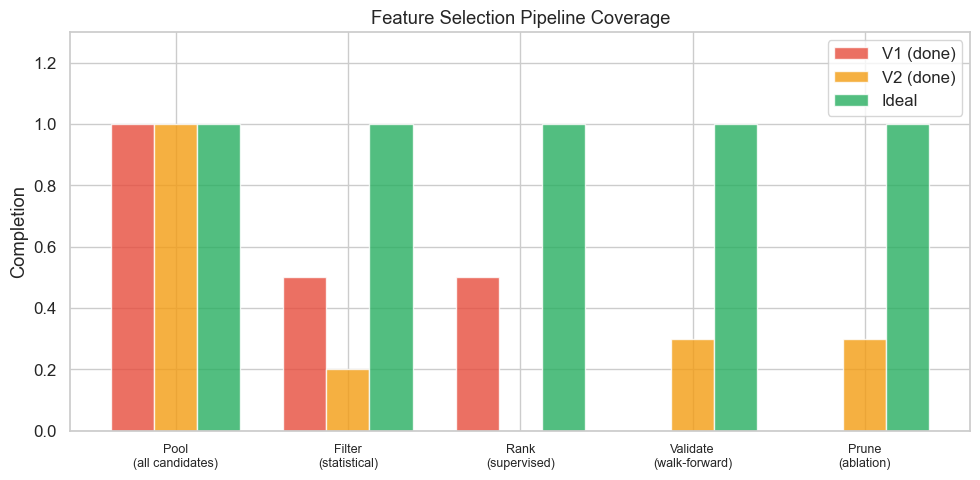

In [5]:
stages = ["Pool\n(all candidates)", "Filter\n(statistical)", "Rank\n(supervised)", "Validate\n(walk-forward)", "Prune\n(ablation)"]
done_v1 = [1, 0.5, 0.5, 0, 0]
done_v2 = [1, 0.2, 0, 0.3, 0.3]
ideal  = [1, 1, 1, 1, 1]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(stages))
w = 0.25
ax.bar(x - w, done_v1, w, label="V1 (done)", color="#e74c3c", alpha=0.8)
ax.bar(x, done_v2, w, label="V2 (done)", color="#f39c12", alpha=0.8)
ax.bar(x + w, ideal, w, label="Ideal", color="#27ae60", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=9)
ax.set_ylabel("Completion")
ax.set_title("Feature Selection Pipeline Coverage")
ax.legend()
ax.set_ylim(0, 1.3)
plt.tight_layout()
plt.savefig(REPO / "lab" / "figures" / "04_audit_pipeline_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Proposed New Feature Set

### 5.1 Design Principles

Based on the audit findings, the new feature set follows these principles:

1. **Information diversity** — draw from multiple independent information sources, not just OHLCV transformations
2. **Stationarity by construction** — features should be ratios, z-scores, or ranks, never raw levels
3. **ATR-normalization** — distances and magnitudes scaled by current volatility regime
4. **Minimal redundancy** — at most 2 features per information type (short-window and long-window)
5. **Target alignment** — features should predict the *type* of move the target captures (direction + magnitude for TBM, direction for fixed horizon)
6. **Cross-asset context** — include at least one exogenous information source

### 5.2 Proposed Feature Categories

#### Category 1: Volatility Regime (6 features) — RETAIN & ENHANCE

**Rationale:** Volatility regime is the strongest predictor class in our experiments. The BK squeeze ratio achieved the highest individual feature AUC in ablation tests.

| Feature | Construction | Why |
|---------|-------------|-----|
| `vol_term_structure` | `vol_short / vol_long` (e.g., 12h / 72h) | Ratio < 1 = compression (pre-expansion); ratio > 1 = expansion |
| `vol_bk_squeeze_ratio` | BB_width / Keltner_width (20-bar) | Below 1.0 = vol compressed below normal — expansion imminent |
| `vol_gk_72_zscore` | `(GK_72 - GK_72.rolling(720).mean()) / GK_72.rolling(720).std()` | Current vol relative to 1-month history |
| `vol_atr_regime` | `ATR_20_pct.rolling(720).rank(pct=True)` | Percentile rank of current vol in 1-month window |
| `vol_parkinson_ratio` | `Park_vol_24 / Park_vol_168` | Intraday vol relative to weekly — regime shift detection |
| `vol_realized_vs_implied` | If IV data available: `RV / IV`; else: `vol_short / vol_long_ema` | Variance risk premium proxy |

#### Category 2: Momentum & Mean Reversion (6 features) — REDESIGN

**Rationale:** Raw returns are noise; normalized momentum with trend decomposition captures actual signal.

| Feature | Construction | Why |
|---------|-------------|-----|
| `mom_norm_24h` | `ret_24h / vol_24h` | Return normalized by volatility = realized Sharpe at 24h |
| `mom_norm_72h` | `ret_72h / vol_72h` | Same at 72h — captures multi-day trends |
| `mom_acceleration` | `mom_norm_24h - mom_norm_24h.shift(24)` | Change in momentum = second derivative |
| `mom_coherence` | `sign(ret_6h) * sign(ret_24h) * sign(ret_72h)` | +1 = all aligned, -1 = conflicting |
| `mean_rev_zscore` | `(close - EMA_72) / (ATR_72)` | ATR-normalized deviation from trend |
| `mean_rev_hurst` | Rolling Hurst exponent, 168h | > 0.5 = trending, < 0.5 = mean-reverting |

#### Category 3: Market Microstructure (6 features) — NEW

**Rationale:** Microstructure features capture order flow dynamics invisible to standard TA.

| Feature | Construction | Why |
|---------|-------------|-----|
| `micro_kyle_lambda` | Regression slope: `|Δprice| ~ volume` over 24h rolling window | Kyle (1985) price impact — measures market depth/liquidity |
| `micro_amihud_illiq` | `mean(|ret_1h| / volume_1h)` over 24h | Amihud (2002) illiquidity — high = thin market |
| `micro_volume_clock` | `cumulative_vol / expected_daily_vol` (rolling mean) | Information arrival rate — fast volume = informed trading |
| `micro_trade_intensity` | `n_trades / volume` (if available; else: `vol_ratio_1h`) | Distinguishes whale orders from retail flow |
| `micro_vpin` | Volume-synchronized probability of informed trading | Order flow toxicity measure (Easley et al., 2012) |
| `micro_roll_spread` | `2 * sqrt(-cov(Δp_t, Δp_{t-1}))` | Roll (1984) effective spread estimate |

#### Category 4: Structural Price Action (4 features) — SIMPLIFY

**Rationale:** Keep swing distances but normalize by ATR and reduce redundancy.

| Feature | Construction | Why |
|---------|-------------|-----|
| `struct_dist_resistance_atr` | `(close - nearest_swing_high) / ATR_72` | ATR-normalized distance to resistance |
| `struct_dist_support_atr` | `(close - nearest_swing_low) / ATR_72` | ATR-normalized distance to support |
| `struct_range_position` | `(close - low_72) / (high_72 - low_72)` | Where in the recent range are we? |
| `struct_wick_rejection` | `max(upper_wick, lower_wick) / body_ratio` | Rejection strength relative to conviction |

#### Category 5: Volume & Liquidity (4 features) — SIMPLIFY

| Feature | Construction | Why |
|---------|-------------|-----|
| `liq_vwap_dev_atr` | `(close - VWAP_24h) / ATR_72` | ATR-normalized VWAP deviation |
| `liq_volume_anomaly` | `vol_12h / vol_72h` | Short-term volume spike relative to baseline |
| `liq_obv_divergence` | `sign(Δ_OBV_24) ≠ sign(Δ_price_24)` | Price-volume divergence |
| `liq_absorption_ratio` | `Σ(vol on doji bars) / Σ(total vol)` over 24h | Volume absorbed without price movement |

#### Category 6: Cross-Asset & Macro Context (4 features) — NEW

**Rationale:** BTC price is driven by macro factors (DXY, rates, risk appetite) and crypto-specific dynamics (ETH ratio, dominance). Single-asset models miss these entirely.

| Feature | Construction | Why |
|---------|-------------|-----|
| `cross_eth_btc_mom` | `ret_24h(ETHUSDT) - ret_24h(BTCUSDT)` | ETH outperformance = risk-on; underperformance = flight to BTC |
| `cross_altcoin_breadth` | `Σ(sign(ret_24h(top10))) / 10` | Market breadth — confirms or denies BTC move |
| `cross_btc_dominance_chg` | `Δ BTC_dom_24h` | Rising dominance = risk-off rotation into BTC |
| `cross_usdt_dom_chg` | `Δ USDT_dom_24h` (or use USDT market cap data) | Rising USDT dominance = risk-off / capital exiting crypto |

#### Category 7: Session & Calendar (2 features) — MINIMAL

| Feature | Construction | Why |
|---------|-------------|-----|
| `cal_session_phase` | `sin(2π × hour / 24)` | Minimal intraday cyclical — captures London/NY volume |
| `cal_weekend` | Binary: Saturday/Sunday | Reduced liquidity/vol on weekends |

### 5.3 Total Count: 32 Features

Compared to V2's 39, we have fewer features but higher information density per feature.

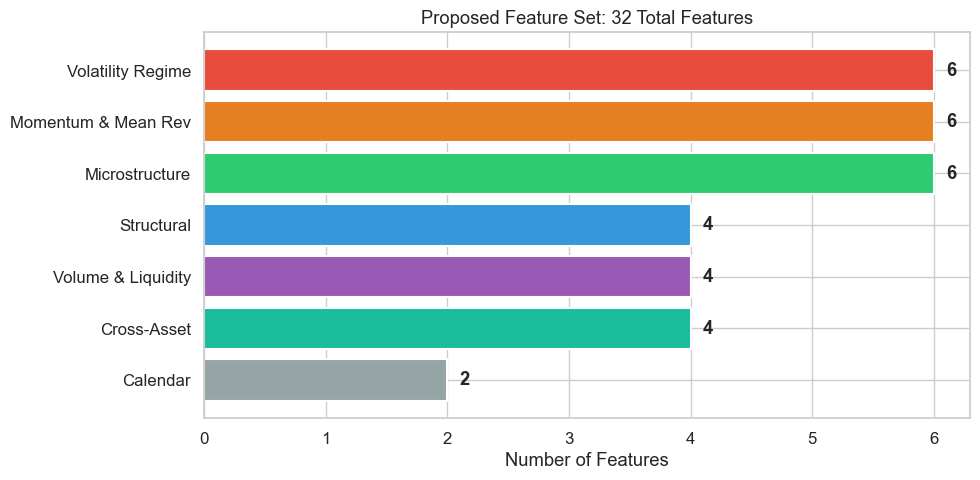


=== Comparison ===


,Set,Total,Effective Rank,Cross-Asset,Microstructure
0,V0 (features.py),12,~7,No,No
1,V1 (registry v1),196,~40,No,No
2,V2 (registry v2),39,~25,No,No
3,V3 (proposed),32,~30,Yes (4),Yes (6)


In [6]:
proposed = {
    "Volatility Regime": ["vol_term_structure", "vol_bk_squeeze_ratio", "vol_gk_72_zscore",
                          "vol_atr_regime", "vol_parkinson_ratio", "vol_realized_vs_implied"],
    "Momentum & Mean Rev": ["mom_norm_24h", "mom_norm_72h", "mom_acceleration",
                             "mom_coherence", "mean_rev_zscore", "mean_rev_hurst"],
    "Microstructure": ["micro_kyle_lambda", "micro_amihud_illiq", "micro_volume_clock",
                       "micro_trade_intensity", "micro_vpin", "micro_roll_spread"],
    "Structural": ["struct_dist_resistance_atr", "struct_dist_support_atr",
                   "struct_range_position", "struct_wick_rejection"],
    "Volume & Liquidity": ["liq_vwap_dev_atr", "liq_volume_anomaly",
                           "liq_obv_divergence", "liq_absorption_ratio"],
    "Cross-Asset": ["cross_eth_btc_mom", "cross_altcoin_breadth",
                    "cross_btc_dominance_chg", "cross_usdt_dom_chg"],
    "Calendar": ["cal_session_phase", "cal_weekend"],
}

fig, ax = plt.subplots(figsize=(10, 5))
cats = list(proposed.keys())
counts = [len(v) for v in proposed.values()]
colors = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db", "#9b59b6", "#1abc9c", "#95a5a6"]
bars = ax.barh(cats, counts, color=colors, edgecolor="white", linewidth=1.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(count), va="center", fontweight="bold")
ax.set_xlabel("Number of Features")
ax.set_title(f"Proposed Feature Set: {sum(counts)} Total Features")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(REPO / "lab" / "figures" / "04_audit_proposed_features.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Comparison ===")
comparison = pd.DataFrame([
    {"Set": "V0 (features.py)", "Total": 12, "Effective Rank": "~7", "Cross-Asset": "No", "Microstructure": "No"},
    {"Set": "V1 (registry v1)", "Total": 196, "Effective Rank": "~40", "Cross-Asset": "No", "Microstructure": "No"},
    {"Set": "V2 (registry v2)", "Total": 39, "Effective Rank": "~25", "Cross-Asset": "No", "Microstructure": "No"},
    {"Set": "V3 (proposed)", "Total": 32, "Effective Rank": "~30", "Cross-Asset": "Yes (4)", "Microstructure": "Yes (6)"},
])
display(comparison)

### 5.4 Implementation Priority

Features are prioritized by expected signal quality and implementation difficulty:

| Priority | Category | Expected Impact | Difficulty | Notes |
|----------|----------|----------------|------------|-------|
| **P0** | Volatility Regime | HIGH | LOW | Mostly retained from V2 with minor enhancements |
| **P0** | Momentum (normalized) | HIGH | LOW | Simple transformations of existing returns |
| **P1** | Microstructure | HIGH | MEDIUM | Kyle lambda and Amihud require careful rolling regression |
| **P1** | Cross-Asset | MEDIUM-HIGH | MEDIUM | Requires multi-asset data pipeline (already have OHLCV for top 10) |
| **P2** | Structural (simplified) | MEDIUM | LOW | Simplification of existing V2 Group A |
| **P2** | Volume & Liquidity | MEDIUM | LOW | Simplification of existing V2 Group B |
| **P3** | Calendar | LOW | TRIVIAL | Keep minimal — possibly drop entirely |

---
## 6. Proposed Feature Selection System

### 6.1 System Overview

A repeatable 5-stage pipeline to be run **before every modeling iteration**:

```
Stage 0: Build            Generate all candidate features from raw OHLCV
    ↓
Stage 1: Statistical      Variance filter, ADF stationarity, pairwise correlation
    Filter                → removes ~30-40% of candidates
    ↓
Stage 2: Univariate       MI(feature, target), Spearman rank correlation
    Rank                  → ranks features, keeps top-K by MI
    ↓
Stage 3: Walk-Forward     Rolling 3-month window MI stability test
    Validate              → removes features with unstable MI across windows
    ↓
Stage 4: Model-Based      Train LGBM with permutation importance
    Prune                 → keeps only features whose removal hurts OOS AUC
    ↓
Stage 5: Final Set        15-25 features → ready for modeling
```

### 6.2 Stage 1: Statistical Filter (Code)

Applied to the full candidate pool before any supervised analysis:

In [7]:
def stage1_statistical_filter(
    df: pd.DataFrame,
    feature_cols: list[str],
    var_threshold: float = 1e-6,
    corr_threshold: float = 0.85,
    target_col: str = "label",
) -> list[str]:
    """Stage 1: Remove near-constant and highly correlated features.

    For correlated pairs, keeps the feature with higher |Spearman(feature, target)|.
    """
    survivors = []

    variances = df[feature_cols].var()
    low_var = variances[variances < var_threshold].index.tolist()
    candidates = [f for f in feature_cols if f not in low_var]
    print(f"  Variance filter: {len(low_var)} removed (threshold={var_threshold})")

    corr_matrix = df[candidates].corr(method="spearman").abs()
    target_corr = df[candidates].corrwith(df[target_col], method="spearman").abs()

    to_drop = set()
    for i in range(len(candidates)):
        if candidates[i] in to_drop:
            continue
        for j in range(i + 1, len(candidates)):
            if candidates[j] in to_drop:
                continue
            if corr_matrix.iloc[i, j] > corr_threshold:
                drop = candidates[j] if target_corr[candidates[i]] >= target_corr[candidates[j]] else candidates[i]
                to_drop.add(drop)

    survivors = [f for f in candidates if f not in to_drop]
    print(f"  Correlation filter: {len(to_drop)} removed (threshold={corr_threshold})")
    print(f"  Survivors: {len(survivors)} / {len(feature_cols)}")
    return survivors


print("Stage 1 function defined. Usage:")
print('  survivors = stage1_statistical_filter(df_train, feature_cols, target_col="label")')

Stage 1 function defined. Usage:
  survivors = stage1_statistical_filter(df_train, feature_cols, target_col="label")


### 6.3 Stage 2: Univariate Ranking (Code)

In [8]:
from sklearn.feature_selection import mutual_info_classif


def stage2_univariate_rank(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "label",
    top_k: int | None = None,
) -> pd.DataFrame:
    """Stage 2: Rank features by mutual information with target.

    Returns DataFrame with columns [feature, MI, spearman_rho, rank].
    """
    X = df[feature_cols].fillna(0).values
    y = df[target_col].values

    mi_scores = mutual_info_classif(X, y, n_neighbors=5, random_state=42)
    spearman_rho = df[feature_cols].corrwith(df[target_col], method="spearman")

    ranking = pd.DataFrame({
        "feature": feature_cols,
        "MI": mi_scores,
        "spearman_rho": spearman_rho.values,
        "abs_rho": spearman_rho.abs().values,
    }).sort_values("MI", ascending=False).reset_index(drop=True)
    ranking["rank"] = range(1, len(ranking) + 1)

    if top_k:
        ranking = ranking.head(top_k)
        print(f"  Top {top_k} features by MI selected")

    return ranking


print("Stage 2 function defined. Usage:")
print('  ranking = stage2_univariate_rank(df_train, survivors, target_col="label", top_k=25)')

Stage 2 function defined. Usage:
  ranking = stage2_univariate_rank(df_train, survivors, target_col="label", top_k=25)


### 6.4 Stage 3: Walk-Forward Feature Stability (Code)

In [9]:
def stage3_walk_forward_stability(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "label",
    window_size: int = 2160,  # 3 months at 1h, or ~15 days at 5m × 288
    step_size: int = 720,     # 1 month
    min_stable_frac: float = 0.6,
    top_k_per_window: int = 20,
) -> list[str]:
    """Stage 3: Keep features that rank in top-K across >= min_stable_frac of windows."""
    n = len(df)
    windows = []
    start = 0
    while start + window_size <= n:
        windows.append((start, start + window_size))
        start += step_size

    print(f"  Walk-forward: {len(windows)} windows of {window_size} bars, step {step_size}")

    appearance_count = {f: 0 for f in feature_cols}

    for i, (s, e) in enumerate(windows):
        chunk = df.iloc[s:e]
        if chunk[target_col].nunique() < 2:
            continue
        X = chunk[feature_cols].fillna(0).values
        y = chunk[target_col].values
        mi = mutual_info_classif(X, y, n_neighbors=5, random_state=42)
        top_idx = np.argsort(mi)[-top_k_per_window:]
        for idx in top_idx:
            appearance_count[feature_cols[idx]] += 1

    total_windows = len(windows)
    stable = [f for f, count in appearance_count.items()
              if count / total_windows >= min_stable_frac]

    print(f"  Stable features (appear in top-{top_k_per_window} in >={min_stable_frac*100:.0f}% of windows): {len(stable)} / {len(feature_cols)}")
    return stable


print("Stage 3 function defined.")
print("This is the most critical stage — features that are not stable across time windows are noise.")

Stage 3 function defined.
This is the most critical stage — features that are not stable across time windows are noise.


### 6.5 Stage 4: Model-Based Pruning (Code)

In [10]:
def stage4_permutation_prune(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    feature_names: list[str],
    n_repeats: int = 5,
    threshold: float = 0.001,
) -> list[str]:
    """Stage 4: Train LGBM, compute permutation importance, prune features
    whose removal doesn't hurt AUC by more than threshold."""
    import lightgbm as lgb
    from sklearn.inspection import permutation_importance
    from sklearn.metrics import roc_auc_score

    model = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.03, num_leaves=31,
        max_depth=5, subsample=0.7, colsample_bytree=0.7,
        min_child_samples=50, reg_alpha=0.1, reg_lambda=1.0,
        verbose=-1,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False)],
    )

    baseline_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    print(f"  Baseline AUC: {baseline_auc:.4f}")

    perm_result = permutation_importance(
        model, X_val, y_val,
        scoring="roc_auc", n_repeats=n_repeats, random_state=42,
    )

    keep = []
    drop = []
    for i, name in enumerate(feature_names):
        importance = perm_result.importances_mean[i]
        if importance > threshold:
            keep.append(name)
        else:
            drop.append((name, importance))

    print(f"  Keep: {len(keep)} features (permutation importance > {threshold})")
    print(f"  Drop: {len(drop)} features")
    if drop:
        print(f"  Dropped: {[d[0] for d in drop[:10]]}")

    return keep


print("Stage 4 function defined.")
print("Usage: final_features = stage4_permutation_prune(X_train, y_train, X_val, y_val, feature_names)")

Stage 4 function defined.
Usage: final_features = stage4_permutation_prune(X_train, y_train, X_val, y_val, feature_names)


### 6.6 Full Pipeline Integration

In [11]:
def run_feature_selection_pipeline(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    all_features: list[str],
    target_col: str = "label",
    corr_threshold: float = 0.85,
    top_k_mi: int = 25,
    min_stable_frac: float = 0.6,
    perm_threshold: float = 0.001,
) -> dict:
    """Run the full 4-stage feature selection pipeline.

    Returns dict with keys: stage1_survivors, stage2_ranking, stage3_stable, stage4_final
    """
    results = {"initial_count": len(all_features)}

    print("\n" + "="*60)
    print(f"STAGE 1: Statistical Filter ({len(all_features)} candidates)")
    print("="*60)
    s1 = stage1_statistical_filter(df_train, all_features, corr_threshold=corr_threshold, target_col=target_col)
    results["stage1_survivors"] = s1

    print(f"\n" + "="*60)
    print(f"STAGE 2: Univariate Ranking ({len(s1)} candidates)")
    print("="*60)
    s2 = stage2_univariate_rank(df_train, s1, target_col=target_col, top_k=top_k_mi)
    results["stage2_ranking"] = s2
    s2_features = s2["feature"].tolist()

    print(f"\n" + "="*60)
    print(f"STAGE 3: Walk-Forward Stability ({len(s2_features)} candidates)")
    print("="*60)
    s3 = stage3_walk_forward_stability(df_train, s2_features, target_col=target_col, min_stable_frac=min_stable_frac)
    results["stage3_stable"] = s3

    print(f"\n" + "="*60)
    print(f"STAGE 4: Model-Based Pruning ({len(s3)} candidates)")
    print("="*60)
    X_train = df_train[s3].fillna(0).values
    y_train = df_train[target_col].values
    X_val = df_val[s3].fillna(0).values
    y_val = df_val[target_col].values
    s4 = stage4_permutation_prune(X_train, y_train, X_val, y_val, s3, threshold=perm_threshold)
    results["stage4_final"] = s4

    print(f"\n" + "="*60)
    print(f"PIPELINE COMPLETE")
    print(f"  {len(all_features)} → {len(s1)} → {len(s2_features)} → {len(s3)} → {len(s4)}")
    print("="*60)

    return results


print("Full pipeline function defined.")
print("")
print("Usage:")
print("  results = run_feature_selection_pipeline(")
print("      df_train, df_val, all_feature_cols,")
print("      target_col='label', corr_threshold=0.85")
print("  )")
print("  final_features = results['stage4_final']")

Full pipeline function defined.

Usage:
  results = run_feature_selection_pipeline(
      df_train, df_val, all_feature_cols,
      target_col='label', corr_threshold=0.85
  )
  final_features = results['stage4_final']


---
## 7. Summary & Action Items

### 7.1 Key Findings

1. **Feature redundancy is massive.** V1 had ~196→40 effective features. V2 has ~39→25 effective features. Neither introduces genuinely new information beyond OHLCV transformations.

2. **Both model classes (LGBM and Mamba) plateau at the same AUC ceiling** (~0.55–0.57), confirming the bottleneck is in the features, not the model architecture.

3. **The strongest feature category is volatility regime** (BK squeeze, ATR regime, GK vol). The weakest are calendar/session features and raw returns.

4. **A confirmed lookahead leak** in V2 Group D (MTF features) inflated early AUC results. Post-patch, these features add no value.

5. **The feature selection process has critical gaps:** no univariate filtering, no walk-forward stability testing, no permutation importance. Features are selected by intuition, not by evidence.

6. **Single-asset myopia** is the biggest structural weakness. All features are transformations of BTCUSDT OHLCV. Cross-asset dynamics, derivatives data, and market microstructure signals are entirely missing.

### 7.2 Action Items

| Priority | Action | Expected Impact |
|----------|--------|-----------------|
| **P0** | Implement V3 feature set (32 features) with microstructure and cross-asset categories | Break the single-asset information ceiling |
| **P0** | Run Stage 1–4 feature selection pipeline on V3 before any modeling | Prevent wasting compute on noise features |
| **P1** | Add Amihud illiquidity and Kyle's lambda as standard microstructure features | Capture order flow dynamics invisible to standard TA |
| **P1** | Build cross-asset pipeline using existing multi-coin OHLCV data (ETH, BNB, SOL, etc.) | 4 new features from already-available data |
| **P2** | Remove calendar/session features unless MI test shows significance | Reduce noise dimensions |
| **P2** | Switch swing distance normalization to ATR-based | Make structural features regime-invariant |
| **P3** | Investigate derivatives data sources (funding rates, open interest) | Potential high-alpha features, but requires new data pipeline |

### 7.3 Expected Outcome

If the root cause diagnosis is correct (feature weakness, not model weakness), the V3 feature set with proper selection should achieve:

| Metric | Current Best | Target |
|--------|-------------|--------|
| OOS AUC | 0.575 (0 trades) | > 0.58 with tradeable signal count |
| EV per Trade | 0.48% (35 trades) | > 0.40% with > 50 trades |
| Feature Stability | Not measured | > 60% of features stable across 3-month windows |
| Effective Feature Rank | ~25/39 | > 28/32 |

If V3 features also plateau at ~0.55 AUC, the conclusion is that **hourly/5-minute OHLCV data from a single exchange does not contain sufficient information to predict BTC price movements at the 24h horizon**, and the project should pivot to:
- Derivatives-based signals (funding rate, OI)
- On-chain data
- Alternative data (social sentiment, news)
- Shorter prediction horizons (1–4h) with tighter risk management